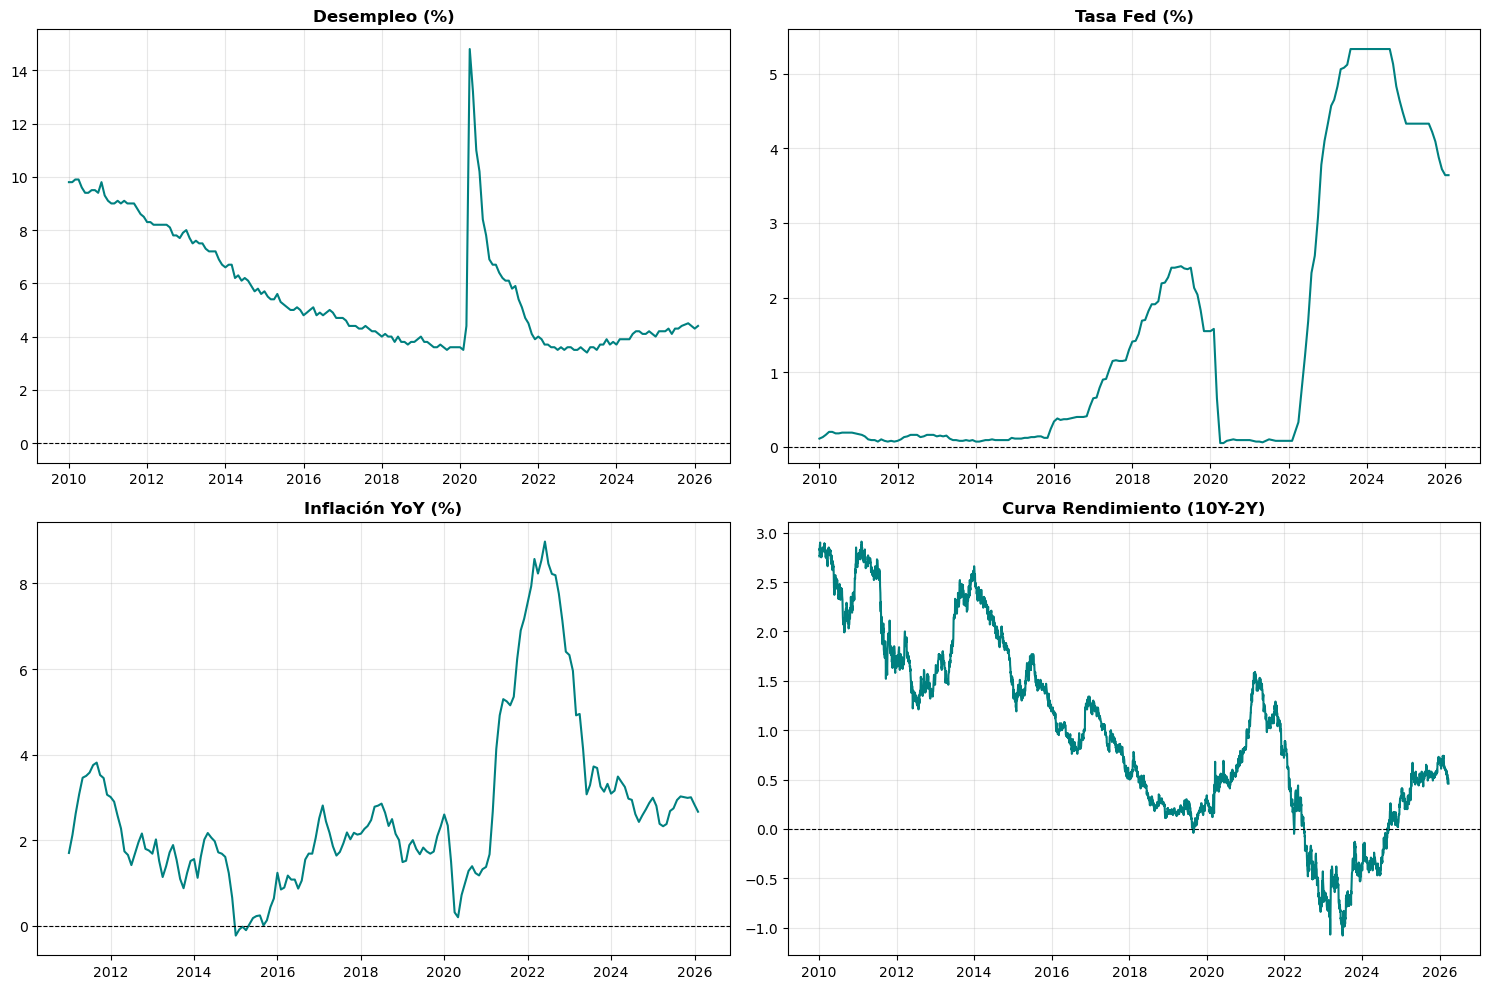

In [5]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

# Configuración
API_KEY = "7f70db551265ea6a1ab3f3fa27271c57"
BASE_URL = "https://api.stlouisfed.org/fred/series/observations"

# Diccionario de indicadores clave (Series ID de FRED)
# UNRATE: Desempleo | FEDFUNDS: Tasa interés Fed | CPIAUCSL: Inflación (IPC) | T10Y2Y: Curva de rendimiento
series_ids = {
    "Desempleo (%)": "UNRATE",
    "Tasa Fed (%)": "FEDFUNDS",
    "Inflación YoY (%)": "CPIAUCSL",
    "Curva Rendimiento (10Y-2Y)": "T10Y2Y"
}

def get_fred_data(series_id):
    params = {
        "series_id": series_id,
        "api_key": API_KEY,
        "file_type": "json",
        "observation_start": "2010-01-01" # Ajusta la fecha según tu estudio
    }
    response = requests.get(BASE_URL, params=params)
    if response.status_code == 200:
        data = response.json()['observations']
        df = pd.DataFrame(data)
        df['date'] = pd.to_datetime(df['date'])
        # Convertimos 'value' a numérico, ignorando errores (puntos vacíos '.' en FRED)
        df['value'] = pd.to_numeric(df['value'], errors='coerce')
        return df[['date', 'value']].dropna()
    else:
        print(f"Error en {series_id}: {response.status_code}")
        return None

# Descarga y Visualización
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
axes = axes.flatten()

for i, (name, s_id) in enumerate(series_ids.items()):
    df = get_fred_data(s_id)
    if df is not None:
        # Cálculo especial para Inflación (Cambio porcentual anual)
        if s_id == "CPIAUCSL":
            df['value'] = df['value'].pct_change(periods=12) * 100
            df = df.dropna()
        
        axes[i].plot(df['date'], df['value'], label=name, color='teal')
        axes[i].set_title(name, fontsize=12, fontweight='bold')
        axes[i].grid(True, alpha=0.3)
        axes[i].axhline(0, color='black', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.show()

In [6]:
import requests
import pandas as pd
from datetime import datetime

# Configuración
API_KEY = "7f70db551265ea6a1ab3f3fa27271c57"
BASE_URL = "https://api.stlouisfed.org/fred/series/observations"

# Diccionario de indicadores con sus nombres legibles
series_ids = {
    "Tasa de Desempleo": "UNRATE",
    "Tasa Interés Fed": "FEDFUNDS",
    "IPC (Nivel Índice)": "CPIAUCSL",
    "Curva Rendimiento (10Y-2Y)": "T10Y2Y",
    "PIB Real (Variación trimestral)": "A191RL1Q225SBEA"
}

def get_latest_fred_value(series_id):
    params = {
        "series_id": series_id,
        "api_key": API_KEY,
        "file_type": "json",
        "sort_order": "desc", # Trae los más nuevos primero
        "limit": 1
    }
    response = requests.get(BASE_URL, params=params)
    if response.status_code == 200:
        obs = response.json()['observations'][0]
        return obs['date'], obs['value']
    return None, None

# Recolección de datos
resultados = []
for nombre, s_id in series_ids.items():
    fecha, valor = get_latest_fred_value(s_id)
    if fecha:
        resultados.append({"Indicador": nombre, "Fecha": fecha, "Valor": valor})

# Presentación en DataFrame
df_resumen = pd.DataFrame(resultados)

# Mostrar tabla
print(f"--- Resumen Macroeconómico Actual ({datetime.now().strftime('%Y-%m-%d')}) ---")
display(df_resumen)

--- Resumen Macroeconómico Actual (2026-03-27) ---


,Indicador,Fecha,Valor
0,Tasa de Desempleo,2026-02-01,4.4
1,Tasa Interés Fed,2026-02-01,3.64
2,IPC (Nivel Índice),2026-02-01,327.460
3,Curva Rendimiento (10Y-2Y),2026-03-26,0.46
4,PIB Real (Variación trimestral),2025-10-01,0.7


In [1]:
import requests
import pandas as pd
from datetime import datetime

# ── Configuración ──────────────────────────────────────────────────────────────
API_KEY  = "7f70db551265ea6a1ab3f3fa27271c57"
BASE_URL = "https://api.stlouisfed.org/fred/series/observations"

# ── Series a descargar ─────────────────────────────────────────────────────────
# Formato: "Nombre legible": ("SERIES_ID", unidad, descripción corta)
SERIES = {
    "Tasa de Desempleo":            ("UNRATE",          "%",     "Mercado laboral"),
    "Tasa Fed Funds (objetivo sup)":("DFEDTARU",        "%",     "Política monetaria"),
    "IPC (índice nivel)":           ("CPIAUCSL",        "índice","Base cálculo inflación"),
    "IPC Subyacente (core)":        ("CPILFESL",        "índice","Sin alimentos ni energía"),
    "Curva Rendimiento 10Y-2Y":     ("T10Y2Y",          "pp",    "Spread de tasas"),
    "Bono 2Y":                      ("DGS2",            "%",     "Parte corta curva"),
    "Bono 10Y":                     ("DGS10",           "%",     "Parte larga curva"),
    "PIB Real (var. trimestral)":   ("A191RL1Q225SBEA", "%",     "Crecimiento económico"),
    "Nóminas no agrícolas (NFP)":   ("PAYEMS",          "miles", "Empleo total"),
    "Ventas minoristas":            ("RSAFS",           "M USD", "Consumo"),
    "Expectativas inflación 5Y":    ("T5YIE",           "%",     "Credibilidad Fed"),
    "Cond. financieras (NFCI)":     ("NFCI",            "índice","Crédito+liquidez+riesgo"),
    "VIX (rezago 1 día)":           ("VIXCLS",          "puntos","Volatilidad implícita"),
    "Permisos de construcción":     ("PERMIT",          "miles", "Indicador líder"),
    "Crédito al consumo":           ("TOTALSL",         "M USD", "Estrés financiero"),
}

# ── Semáforo de interpretación ─────────────────────────────────────────────────
def interpretar(nombre, valor):
    """Devuelve (estado, nota) según umbrales económicos estándar."""
    try:
        v = float(valor)
    except (ValueError, TypeError):
        return "—", "Sin dato"

    reglas = {
        "Tasa de Desempleo": [
            (4.0,  "✅ OK",    "Pleno empleo"),
            (5.5,  "⚠️ ALERTA","Mercado laboral enfriando"),
            (float("inf"), "🔴 RIESGO", "Desempleo elevado"),
        ],
        "Tasa Fed Funds (objetivo sup)": [
            (2.5,  "✅ OK",    "Política acomodaticia"),
            (4.5,  "⚠️ ALERTA","Política restrictiva moderada"),
            (float("inf"), "🔴 RIESGO", "Política muy restrictiva"),
        ],
        "IPC Anual (%)": [
            (2.5,  "✅ OK",    "Cerca del objetivo 2%"),
            (4.0,  "⚠️ ALERTA","Inflación elevada"),
            (float("inf"), "🔴 RIESGO", "Inflación muy alta"),
        ],
        "IPC Subyacente Anual (%)": [
            (2.5,  "✅ OK",    "Core bajo control"),
            (4.0,  "⚠️ ALERTA","Core persistente"),
            (float("inf"), "🔴 RIESGO", "Core muy elevado"),
        ],
        "Curva Rendimiento 10Y-2Y": [
            (-0.01, "🔴 RIESGO","Curva invertida — señal recesión"),
            (0.5,   "⚠️ ALERTA","Curva plana o normalizando"),
            (float("inf"), "✅ OK", "Curva normal"),
        ],
        "PIB Real (var. trimestral)": [
            (0.0,  "🔴 RIESGO","Contracción"),
            (1.5,  "⚠️ ALERTA","Crecimiento débil"),
            (float("inf"), "✅ OK", "Crecimiento sano"),
        ],
        "VIX (rezago 1 día)": [
            (20.0, "✅ OK",    "Baja volatilidad"),
            (30.0, "⚠️ ALERTA","Volatilidad elevada"),
            (float("inf"), "🔴 RIESGO", "Pánico / stress sistémico"),
        ],
        "Expectativas inflación 5Y": [
            (2.5,  "✅ OK",    "Bien ancladas"),
            (3.0,  "⚠️ ALERTA","Expectativas subiendo"),
            (float("inf"), "🔴 RIESGO", "Desancladas"),
        ],
        "Cond. financieras (NFCI)": [
            (0.0,  "✅ OK",    "Condiciones laxas"),
            (0.5,  "⚠️ ALERTA","Condiciones tensionando"),
            (float("inf"), "🔴 RIESGO", "Condiciones muy restrictivas"),
        ],
    }

    for umbral, estado, nota in reglas.get(nombre, []):
        if v <= umbral:
            return estado, nota
    return "—", "Ver contexto"


# ── Funciones de descarga ──────────────────────────────────────────────────────
def get_observations(series_id, limit=2, sort_order="desc"):
    """Trae las últimas `limit` observaciones de una serie FRED."""
    params = {
        "series_id":  series_id,
        "api_key":    API_KEY,
        "file_type":  "json",
        "sort_order": sort_order,
        "limit":      limit,
    }
    try:
        r = requests.get(BASE_URL, params=params, timeout=10)
        r.raise_for_status()
        obs = r.json().get("observations", [])
        # FRED devuelve "." cuando no hay dato aún
        return [o for o in obs if o["value"] != "."]
    except Exception as e:
        print(f"  ⚠ Error en {series_id}: {e}")
        return []


def calcular_variacion_anual(series_id):
    """
    Para series de nivel (IPC), descarga 13 meses y calcula la variación
    porcentual anual: (valor_actual / valor_hace_12_meses - 1) * 100
    """
    params = {
        "series_id":  series_id,
        "api_key":    API_KEY,
        "file_type":  "json",
        "sort_order": "desc",
        "limit":      13,
    }
    try:
        r = requests.get(BASE_URL, params=params, timeout=10)
        r.raise_for_status()
        obs = [o for o in r.json().get("observations", []) if o["value"] != "."]
        if len(obs) >= 13:
            v_actual   = float(obs[0]["value"])
            v_anterior = float(obs[12]["value"])
            variacion  = (v_actual / v_anterior - 1) * 100
            return obs[0]["date"], round(variacion, 2)
    except Exception as e:
        print(f"  ⚠ Error calculando variación anual de {series_id}: {e}")
    return None, None


# ── Recolección principal ──────────────────────────────────────────────────────
print(f"\n{'='*65}")
print(f"  RESUMEN MACROECONÓMICO USA — {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print(f"{'='*65}\n")
print("  Descargando datos desde FRED...")

resultados = []

for nombre, (s_id, unidad, desc) in SERIES.items():

    # IPC y core: calcular variación anual
    if s_id in ("CPIAUCSL", "CPILFESL"):
        fecha, valor = calcular_variacion_anual(s_id)
        nombre_display = nombre.replace("(índice nivel)", "Anual (%)")
        unidad_display = "%"
    else:
        obs = get_observations(s_id, limit=1)
        if obs:
            fecha  = obs[0]["date"]
            valor  = obs[0]["value"]
        else:
            fecha, valor = None, None
        nombre_display = nombre
        unidad_display = unidad

    if fecha and valor is not None:
        estado, nota = interpretar(nombre_display, valor)
        resultados.append({
            "Indicador":  nombre_display,
            "Fecha":      fecha,
            "Valor":      valor,
            "Unidad":     unidad_display,
            "Estado":     estado,
            "Nota":       nota,
            "Descripción":desc,
        })
    else:
        resultados.append({
            "Indicador":  nombre_display,
            "Fecha":      "—",
            "Valor":      "N/D",
            "Unidad":     unidad,
            "Estado":     "—",
            "Nota":       "Sin dato disponible",
            "Descripción":desc,
        })

# ── Presentación ───────────────────────────────────────────────────────────────
df = pd.DataFrame(resultados)

# Columnas para mostrar
df_display = df[["Indicador", "Fecha", "Valor", "Unidad", "Estado", "Nota"]].copy()

# Formatear valores numéricos
def fmt_valor(v, u):
    try:
        n = float(v)
        if u == "%":
            return f"{n:.2f}%"
        elif u == "pp":
            return f"{n:+.2f} pp"
        elif u in ("M USD", "miles"):
            return f"{n:,.0f}"
        else:
            return f"{n:.2f}"
    except (ValueError, TypeError):
        return v

df_display["Valor"] = df.apply(lambda r: fmt_valor(r["Valor"], r["Unidad"]), axis=1)

pd.set_option("display.max_colwidth", 40)
pd.set_option("display.width", 120)

print(df_display.to_string(index=False))

# ── Resumen de semáforo ────────────────────────────────────────────────────────
print(f"\n{'─'*65}")
ok    = sum(1 for r in resultados if "OK"    in r["Estado"])
warn  = sum(1 for r in resultados if "ALERTA" in r["Estado"])
risk  = sum(1 for r in resultados if "RIESGO" in r["Estado"])
total = ok + warn + risk

print(f"  Semáforo: ✅ {ok} OK   ⚠️  {warn} Alerta   🔴 {risk} Riesgo  (sobre {total} indicadores)")
print(f"{'─'*65}\n")

# ── Exportar a CSV (opcional) ──────────────────────────────────────────────────
ts  = datetime.now().strftime("%Y%m%d_%H%M")
csv = f"macro_usa_{ts}.csv"
df.to_csv(csv, index=False)
print(f"  Datos guardados en: {csv}")
print(f"{'='*65}\n")


  RESUMEN MACROECONÓMICO USA — 2026-03-30 19:37

  Descargando datos desde FRED...
                    Indicador      Fecha     Valor Unidad    Estado                          Nota
            Tasa de Desempleo 2026-02-01     4.40%      % ⚠️ ALERTA     Mercado laboral enfriando
Tasa Fed Funds (objetivo sup) 2026-03-30     3.75%      % ⚠️ ALERTA Política restrictiva moderada
                IPC Anual (%)          —       N/D índice         —           Sin dato disponible
        IPC Subyacente (core)          —       N/D índice         —           Sin dato disponible
     Curva Rendimiento 10Y-2Y 2026-03-30  +0.53 pp     pp      ✅ OK                  Curva normal
                      Bono 2Y 2026-03-27     3.88%      %         —                  Ver contexto
                     Bono 10Y 2026-03-27     4.44%      %         —                  Ver contexto
   PIB Real (var. trimestral) 2025-10-01     0.70%      % ⚠️ ALERTA             Crecimiento débil
   Nóminas no agrícolas (NFP) 2026

In [2]:
import requests
import pandas as pd
from datetime import datetime

# ── Configuración ──────────────────────────────────────────────────────────────
API_KEY  = "7f70db551265ea6a1ab3f3fa27271c57"
BASE_URL = "https://api.stlouisfed.org/fred/series/observations"

# ── Series a descargar ─────────────────────────────────────────────────────────
# Formato: "Nombre legible": ("SERIES_ID", unidad, descripción corta)
SERIES = {
    "Tasa de Desempleo":            ("UNRATE",          "%",     "Mercado laboral"),
    "Tasa Fed Funds (objetivo sup)":("DFEDTARU",        "%",     "Política monetaria"),
    "IPC (índice nivel)":           ("CPIAUCSL",        "índice","Base cálculo inflación"),
    "IPC Subyacente (core)":        ("CPILFESL",        "índice","Sin alimentos ni energía"),
    "Curva Rendimiento 10Y-2Y":     ("T10Y2Y",          "pp",    "Spread de tasas"),
    "Bono 2Y":                      ("DGS2",            "%",     "Parte corta curva"),
    "Bono 10Y":                     ("DGS10",           "%",     "Parte larga curva"),
    "PIB Real (var. trimestral)":   ("A191RL1Q225SBEA", "%",     "Crecimiento económico"),
    "Nóminas no agrícolas (NFP)":   ("PAYEMS",          "miles", "Empleo total"),
    "Ventas minoristas":            ("RSAFS",           "M USD", "Consumo"),
    "Expectativas inflación 5Y":    ("T5YIE",           "%",     "Credibilidad Fed"),
    "Cond. financieras (NFCI)":     ("NFCI",            "índice","Crédito+liquidez+riesgo"),
    "VIX (rezago 1 día)":           ("VIXCLS",          "puntos","Volatilidad implícita"),
    "Permisos de construcción":     ("PERMIT",          "miles", "Indicador líder"),
    "Crédito al consumo":           ("TOTALSL",         "M USD", "Estrés financiero"),
}

# ── Semáforo de interpretación ─────────────────────────────────────────────────
def interpretar(nombre, valor):
    """Devuelve (estado, nota) según umbrales económicos estándar."""
    try:
        v = float(valor)
    except (ValueError, TypeError):
        return "—", "Sin dato"

    reglas = {
        "Tasa de Desempleo": [
            (4.0,  "✅ OK",    "Pleno empleo"),
            (5.5,  "⚠️ ALERTA","Mercado laboral enfriando"),
            (float("inf"), "🔴 RIESGO", "Desempleo elevado"),
        ],
        "Tasa Fed Funds (objetivo sup)": [
            (2.5,  "✅ OK",    "Política acomodaticia"),
            (4.5,  "⚠️ ALERTA","Política restrictiva moderada"),
            (float("inf"), "🔴 RIESGO", "Política muy restrictiva"),
        ],
        "IPC Anual (%)": [
            (2.5,  "✅ OK",    "Cerca del objetivo 2%"),
            (4.0,  "⚠️ ALERTA","Inflación elevada"),
            (float("inf"), "🔴 RIESGO", "Inflación muy alta"),
        ],
        "IPC Subyacente Anual (%)": [
            (2.5,  "✅ OK",    "Core bajo control"),
            (4.0,  "⚠️ ALERTA","Core persistente"),
            (float("inf"), "🔴 RIESGO", "Core muy elevado"),
        ],
        "Curva Rendimiento 10Y-2Y": [
            (-0.01, "🔴 RIESGO","Curva invertida — señal recesión"),
            (0.5,   "⚠️ ALERTA","Curva plana o normalizando"),
            (float("inf"), "✅ OK", "Curva normal"),
        ],
        "PIB Real (var. trimestral)": [
            (0.0,  "🔴 RIESGO","Contracción"),
            (1.5,  "⚠️ ALERTA","Crecimiento débil"),
            (float("inf"), "✅ OK", "Crecimiento sano"),
        ],
        "VIX (rezago 1 día)": [
            (20.0, "✅ OK",    "Baja volatilidad"),
            (30.0, "⚠️ ALERTA","Volatilidad elevada"),
            (float("inf"), "🔴 RIESGO", "Pánico / stress sistémico"),
        ],
        "Expectativas inflación 5Y": [
            (2.5,  "✅ OK",    "Bien ancladas"),
            (3.0,  "⚠️ ALERTA","Expectativas subiendo"),
            (float("inf"), "🔴 RIESGO", "Desancladas"),
        ],
        "Cond. financieras (NFCI)": [
            (0.0,  "✅ OK",    "Condiciones laxas"),
            (0.5,  "⚠️ ALERTA","Condiciones tensionando"),
            (float("inf"), "🔴 RIESGO", "Condiciones muy restrictivas"),
        ],
        "Bono 2Y": [
            (3.0,  "✅ OK",    "Tasas cortas bajas"),
            (4.5,  "⚠️ ALERTA","Tasas cortas elevadas"),
            (float("inf"), "🔴 RIESGO", "Tasas cortas muy altas"),
        ],
        "Bono 10Y": [
            (3.5,  "✅ OK",    "Tasas largas moderadas"),
            (4.5,  "⚠️ ALERTA","Tasas largas presionando"),
            (float("inf"), "🔴 RIESGO", "Tasas largas muy altas"),
        ],
        "Nóminas no agrícolas (NFP)": [
            (100,   "🔴 RIESGO","Creación de empleo muy débil"),
            (150,   "⚠️ ALERTA","Empleo desacelerando"),
            (float("inf"), "✅ OK", "Creación de empleo sana"),
        ],
        "Ventas minoristas": [
            (650000, "🔴 RIESGO","Consumo deprimido"),
            (700000, "⚠️ ALERTA","Consumo moderado"),
            (float("inf"), "✅ OK", "Consumo sólido"),
        ],
        "Permisos de construcción": [
            (1000,  "🔴 RIESGO","Construcción muy débil"),
            (1400,  "⚠️ ALERTA","Construcción moderada"),
            (float("inf"), "✅ OK", "Construcción activa"),
        ],
        "Crédito al consumo": [
            (4800000, "✅ OK",   "Crédito en niveles normales"),
            (5200000, "⚠️ ALERTA","Crédito elevado, posible estrés"),
            (float("inf"), "🔴 RIESGO", "Sobreendeudamiento"),
        ],
    }

    for umbral, estado, nota in reglas.get(nombre, []):
        if v <= umbral:
            return estado, nota
    return "—", "Ver contexto"


# ── Funciones de descarga ──────────────────────────────────────────────────────
def get_observations(series_id, limit=2, sort_order="desc"):
    """Trae las últimas `limit` observaciones de una serie FRED."""
    params = {
        "series_id":  series_id,
        "api_key":    API_KEY,
        "file_type":  "json",
        "sort_order": sort_order,
        "limit":      limit,
    }
    try:
        r = requests.get(BASE_URL, params=params, timeout=10)
        r.raise_for_status()
        obs = r.json().get("observations", [])
        # FRED devuelve "." cuando no hay dato aún
        return [o for o in obs if o["value"] != "."]
    except Exception as e:
        print(f"  ⚠ Error en {series_id}: {e}")
        return []


def calcular_variacion_anual(series_id):
    """
    Para series de nivel (IPC), descarga 14 meses para asegurar 13 válidos
    y calcula: (valor_actual / valor_hace_12_meses - 1) * 100
    """
    params = {
        "series_id":  series_id,
        "api_key":    API_KEY,
        "file_type":  "json",
        "sort_order": "desc",
        "limit":      14,          # margen extra por si algún mes tiene "."
    }
    try:
        r = requests.get(BASE_URL, params=params, timeout=10)
        r.raise_for_status()
        obs = [o for o in r.json().get("observations", []) if o["value"] != "."]
        if len(obs) >= 13:
            v_actual   = float(obs[0]["value"])
            v_anterior = float(obs[12]["value"])
            variacion  = (v_actual / v_anterior - 1) * 100
            return obs[0]["date"], round(variacion, 2)
        elif len(obs) >= 2:
            # Fallback: variación mes a mes anualizada si no hay 13 meses
            v_actual   = float(obs[0]["value"])
            v_anterior = float(obs[-1]["value"])
            variacion  = (v_actual / v_anterior - 1) * 100
            print(f"  ℹ {series_id}: solo {len(obs)} obs. válidas, variación aproximada.")
            return obs[0]["date"], round(variacion, 2)
    except Exception as e:
        print(f"  ⚠ Error calculando variación anual de {series_id}: {e}")
    return None, None


# ── Recolección principal ──────────────────────────────────────────────────────
print(f"\n{'='*65}")
print(f"  RESUMEN MACROECONÓMICO USA — {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print(f"{'='*65}\n")
print("  Descargando datos desde FRED...")

resultados = []

for nombre, (s_id, unidad, desc) in SERIES.items():

    # IPC y core: calcular variación anual
    if s_id in ("CPIAUCSL", "CPILFESL"):
        fecha, valor = calcular_variacion_anual(s_id)
        nombre_display = nombre.replace("(índice nivel)", "Anual (%)")
        unidad_display = "%"
    else:
        obs = get_observations(s_id, limit=1)
        if obs:
            fecha  = obs[0]["date"]
            valor  = obs[0]["value"]
        else:
            fecha, valor = None, None
        nombre_display = nombre
        unidad_display = unidad

    if fecha and valor is not None:
        estado, nota = interpretar(nombre_display, valor)
        resultados.append({
            "Indicador":  nombre_display,
            "Fecha":      fecha,
            "Valor":      valor,
            "Unidad":     unidad_display,
            "Estado":     estado,
            "Nota":       nota,
            "Descripción":desc,
        })
    else:
        resultados.append({
            "Indicador":  nombre_display,
            "Fecha":      "—",
            "Valor":      "N/D",
            "Unidad":     unidad,
            "Estado":     "—",
            "Nota":       "Sin dato disponible",
            "Descripción":desc,
        })

# ── Presentación ───────────────────────────────────────────────────────────────
df = pd.DataFrame(resultados)

# Columnas para mostrar
df_display = df[["Indicador", "Fecha", "Valor", "Unidad", "Estado", "Nota"]].copy()

# Formatear valores numéricos
def fmt_valor(v, u):
    try:
        n = float(v)
        if u == "%":
            return f"{n:.2f}%"
        elif u == "pp":
            return f"{n:+.2f} pp"
        elif u in ("M USD", "miles"):
            return f"{n:,.0f}"
        else:
            return f"{n:.2f}"
    except (ValueError, TypeError):
        return v

df_display["Valor"] = df.apply(lambda r: fmt_valor(r["Valor"], r["Unidad"]), axis=1)

pd.set_option("display.max_colwidth", 40)
pd.set_option("display.width", 120)

# Excluir filas sin dato o sin interpretación definida
df_display = df_display[
    ~df_display["Nota"].isin(["Sin dato disponible", "Ver contexto"])
].reset_index(drop=True)

print(df_display.to_string(index=False))

# ── Resumen de semáforo ────────────────────────────────────────────────────────
print(f"\n{'─'*65}")
ok    = sum(1 for r in resultados if "OK"    in r["Estado"])
warn  = sum(1 for r in resultados if "ALERTA" in r["Estado"])
risk  = sum(1 for r in resultados if "RIESGO" in r["Estado"])
total = ok + warn + risk

print(f"  Semáforo: ✅ {ok} OK   ⚠️  {warn} Alerta   🔴 {risk} Riesgo  (sobre {total} indicadores)")
print(f"{'─'*65}\n")

# ── Exportar a CSV (opcional) ──────────────────────────────────────────────────
ts  = datetime.now().strftime("%Y%m%d_%H%M")
csv = f"macro_usa_{ts}.csv"
df.to_csv(csv, index=False)
print(f"  Datos guardados en: {csv}")
print(f"{'='*65}\n")


  RESUMEN MACROECONÓMICO USA — 2026-03-30 19:42

  Descargando datos desde FRED...
                    Indicador      Fecha     Valor Unidad    Estado                            Nota
            Tasa de Desempleo 2026-02-01     4.40%      % ⚠️ ALERTA       Mercado laboral enfriando
Tasa Fed Funds (objetivo sup) 2026-03-30     3.75%      % ⚠️ ALERTA   Política restrictiva moderada
                IPC Anual (%) 2026-02-01     2.66%      % ⚠️ ALERTA               Inflación elevada
     Curva Rendimiento 10Y-2Y 2026-03-30  +0.53 pp     pp      ✅ OK                    Curva normal
                      Bono 2Y 2026-03-27     3.88%      % ⚠️ ALERTA           Tasas cortas elevadas
                     Bono 10Y 2026-03-27     4.44%      % ⚠️ ALERTA        Tasas largas presionando
   PIB Real (var. trimestral) 2025-10-01     0.70%      % ⚠️ ALERTA               Crecimiento débil
   Nóminas no agrícolas (NFP) 2026-02-01   158,466  miles      ✅ OK         Creación de empleo sana
            Vent